In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord

import matplotlib.pyplot as plt
from IPython.display import display
from gammapy.data import EventList
from gammapy.datasets import Datasets, MapDataset
from gammapy.irf import EDispKernelMap, PSFMap
from gammapy.maps import Map, MapAxis, WcsGeom
from gammapy.modeling import Fit
from matplotlib.patches import Circle
from gammapy.modeling.models import (
    Models,
    PointSpatialModel,
    PowerLawNormSpectralModel,
    PowerLawSpectralModel,
    SkyModel,
    TemplateSpatialModel,
    create_fermi_isotropic_diffuse_model,
)
from astropy.table import vstack
from gammapy.data import EventList
from gammapy.catalog import SourceCatalog4FGL

import yaml
from fermipy.gtanalysis import GTAnalysis
from fermipy.plotting import ROIPlotter, SEDPlotter

catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

In [2]:
# Create a GTAnalysis object from the configuration file.
gta = GTAnalysis('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/fermi_config_rcw86_2016_2025years.yaml', logging={'verbosity': 3})

2025-05-08 09:48:25 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.3.1 
ScienceTools version 2.2.0


In [3]:
gta.setup()

2025-05-08 09:48:27 INFO    GTAnalysis.setup(): Running setup.
2025-05-08 09:48:27 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2025-05-08 09:48:27 INFO    GTBinnedAnalysis._select_data(): Skipping data selection.
2025-05-08 09:48:27 INFO    GTBinnedAnalysis._create_ltcube(): Skipping LT Cube.
2025-05-08 09:48:27 INFO    GTBinnedAnalysis._create_expcube(): Skipping gtexpcube.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 57388.000000 from DATE-OBS.
Set MJD-END to 60706.999988 from DATE-END'. [astropy.wcs.wcs]
2025-05-08 09:48:27 INFO    GTBinnedAnalysis._create_srcmaps(): Skipping gtsrcmaps.
2025-05-08 09:48:27 INFO    GTBinnedAnalysis.setup(): Finished setup for component 00
2025-05-08 09:48:27 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2025-05-08 09:48:32 INFO    GTAnalysis.setup(): Initializing source properties
2025-05-08 09:48:34 INFO    GTAnalysis.setup(): Finished setup.


2025-05-08 09:48:43 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_2016_2025/initial_00.xml...
2025-05-08 09:48:43 INFO    GTAnalysis.write_fits(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_2016_2025/initial.fits...
2025-05-08 09:48:46 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 00.
2025-05-08 09:48:48 INFO    GTAnalysis.write_roi(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_2016_2025/initial.npy...


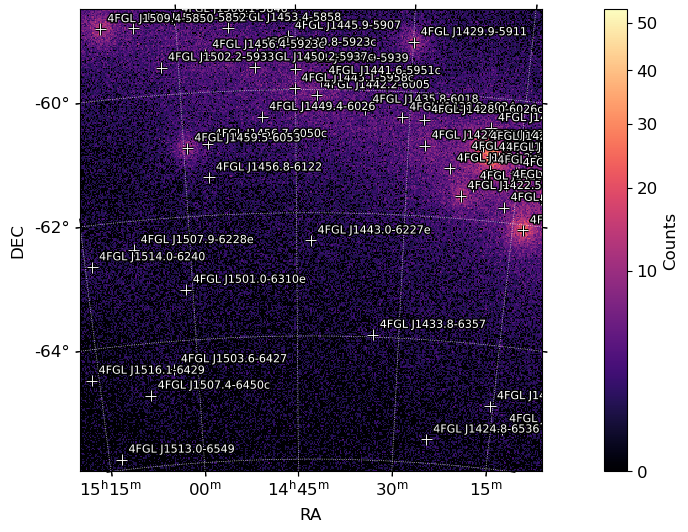

In [4]:
gta.write_roi('initial',make_plots=True,save_model_map=True)
plt.show()

In [5]:
gta.print_model()

2025-05-08 09:48:51 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1443.0-6227e     0.000   1.695  1.33e-05   1.47       nan       188.2     
4FGL J1433.8-6357      1.834   1.790  1.06e-06   2.70       nan       159.0     
4FGL J1456.8-6122      1.942   1.083  9.92e-07   2.26       nan        82.2     
4FGL J1449.4-6026      2.154   2.494  1.86e-06   3.00       nan       302.0     
4FGL J1501.0-6310e     2.178   3.013  1.09e-05   2.49       nan      1360.7     
4FGL J1456.7-6050c     2.290   1.338  2.39e-06   1.42       nan        28.9     
4FGL J1435.8-6018      2.303   1.460  2.75e-06   3.83       nan       528.6     
4FGL J1442.2-6005      2.361   0.408  6.69e-06   2.58       nan       923.2     
4FGL J1427.8-6051      2.409   2.795   8.5e-06   2.62       nan      1164.2     
4FGL J1445.1-5958c     2.484   0.757  3.01e-06   2.61 

In [6]:
source_rcw86 = catalog_4fgl["4FGL J1443.0-6227e"]

### Free parameters around roi center with distance 3 deg.

In [7]:
#gta.free_sources(free=False)
# Around particular source 
#gta.free_sources(skydir=gta.roi[gta.roi.sources[0].name].skydir,distance=[3.0],free=True)
gta.free_sources(distance=[3.0],free=True)
gta.print_model()

2025-05-08 09:48:56 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1443.0-6227e    : ['Prefactor', 'Index']
2025-05-08 09:48:56 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1433.8-6357     : ['norm', 'alpha', 'beta']
2025-05-08 09:48:56 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1456.8-6122     : ['Prefactor', 'Index']
2025-05-08 09:48:56 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1449.4-6026     : ['norm', 'alpha', 'beta']
2025-05-08 09:48:56 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1501.0-6310e    : ['norm', 'alpha', 'beta']
2025-05-08 09:48:57 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1456.7-6050c    : ['Prefactor', 'Index']
2025-05-08 09:48:57 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1435.8-6018     : ['norm', 'alpha', 'beta']
2025-05-08 09:48:57 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1442.2-6005     : ['norm', 'alpha', '

In [8]:
gta.fit()

2025-05-08 09:48:59 INFO    GTAnalysis.fit(): Starting fit.


Drm_Cache::update Measured counts < 0 4FGL J1449.4-6026 21 -1.96606e-11 1.356e-11
0.312833 0.623705 1.02235 1.38132 1.54593 1.44106 1.13249 0.751427 0.414104 0.190759 0.0737193 0.0238596 0.00648674 0.00147266 0.0002766 4.31832e-05 5.61793e-06 6.0969e-07 5.50913e-08 4.15431e-09 2.60634e-10 1.356e-11 


2025-05-08 09:50:18 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   2 Status: 102
2025-05-08 09:50:18 INFO    GTAnalysis.fit(): LogLike:  -461992.666 DeltaLogLike:      644.790 


{'fit_quality': 2,
 'fit_status': 102,
 'fit_success': True,
 'dloglike': 644.7901928699575,
 'edm': 0.0005377654289533642,
 'loglike': -461992.6657620135,
 'covariance': array([[ 1.89163382e-02, -5.69481209e-03, -7.30709438e-04, ...,
         -6.04877257e-06,  4.09673943e-06,  3.27288151e-05],
        [-5.69481209e-03,  9.75141193e-03, -5.87425957e-04, ...,
         -6.21795536e-06, -1.57130770e-06, -4.14977136e-06],
        [-7.30709438e-04, -5.87425957e-04,  6.14638295e-02, ...,
         -1.02126767e-05,  1.37062981e-05,  9.50180844e-05],
        ...,
        [-6.04877257e-06, -6.21795536e-06, -1.02126767e-05, ...,
          3.44801476e-06,  1.00640807e-06, -3.36294117e-05],
        [ 4.09673943e-06, -1.57130770e-06,  1.37062981e-05, ...,
          1.00640807e-06,  4.15524424e-06,  3.26061240e-05],
        [ 3.27288151e-05, -4.14977136e-06,  9.50180844e-05, ...,
         -3.36294117e-05,  3.26061240e-05,  6.29137381e-03]]),
 'correlation': array([[ 1.00000000e+00, -4.19302172e-01, -

In [23]:
gta.print_model()

2025-05-07 23:44:21 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1443.0-6227e     0.000   1.495  1.11e-05   1.53     87.82       183.2    *
4FGL J1433.8-6357      1.834   2.040  1.03e-06   2.93     28.51       156.0    *
4FGL J1456.8-6122      1.942   0.891  7.15e-07   2.59      5.03        87.1    *
4FGL J1449.4-6026      2.154   1.888  1.19e-06   3.09      9.10       188.9    *
4FGL J1501.0-6310e     2.178   2.711  9.13e-06   2.78     64.55      1090.9    *
4FGL J1456.7-6050c     2.290   0.297  1.12e-06   2.46      6.62       119.6    *
4FGL J1435.8-6018      2.303   1.545  2.33e-06   5.33     36.05       516.9    *
4FGL J1442.2-6005      2.361   0.309  5.45e-06   2.73     84.43       792.0    *
4FGL J1427.8-6051      2.409   2.561  8.57e-06   2.88    212.07      1313.2    *
4FGL J1445.1-5958c     2.484   0.739  3.52e-06   2.89 

# TS Map, source excluded

In [9]:
plt.clf()
#tsmap_excluded = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True, exclude = gta.roi.sources[0].name)
tsmap_excluded = gta.tsmap(prefix='TSmap_start',make_plots=True, exclude = gta.roi.sources[0].name)

2025-05-08 09:50:30 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-08 09:50:32 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-08 09:54:42 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-08 09:54:44 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_2016_2025/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-05-08 09:54:44 INFO    GTAnalysis.tsmap(): Execution time: 253.36 s


<Figure size 640x480 with 0 Axes>

In [14]:
gta.roi.sources[0]['ra']

220.76

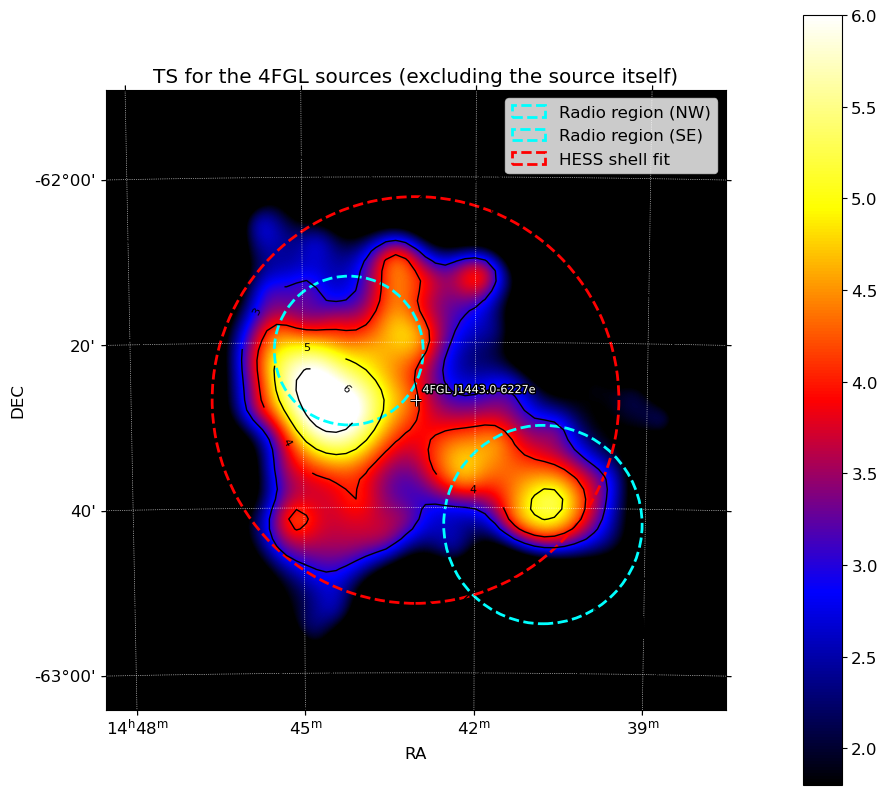

In [28]:
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt

# (your ROIPlotter setup)
p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi,
               cmap='ds9_b',
               label_ts_threshold=10.0)

# make your figure *before* you plot
plt.figure(figsize=(10, 10))

# draw the TS map
p.plot(interpolation='bicubic',
       zoom=6,
       vmin=1.8,
       vmax=6,
       levels=[0, 3, 4, 5, 6])

# define circles
NE_region = SkyCoord(221.05, -62.35, unit='deg', frame='icrs')
SW_region = SkyCoord(220.20, -62.70, unit='deg', frame='icrs')
shell_pos = SkyCoord(gta.roi.sources[0]['ra'],
                     gta.roi.sources[0]['dec'],
                     unit='deg', frame='icrs')

# draw them, using `label=` and *different* labels
c1 = p.draw_circle(0.15, skydir=NE_region,
                   edgecolor='cyan',
                   linewidth=2.0,
                   linestyle='--',
                   label='Radio region (NW)')

c2 = p.draw_circle(0.20, skydir=SW_region,
                   edgecolor='cyan',
                   linewidth=2.0,
                   linestyle='--',
                   label='Radio region (SE)')

c3 = p.draw_circle(0.41, skydir=shell_pos,
                   edgecolor='red',
                   linewidth=2.0,
                   linestyle='--',
                   label='HESS shell fit')

# now make the legend
plt.legend(loc='upper right')
plt.title("TS for the 4FGL sources (excluding the source itself)")
plt.show()

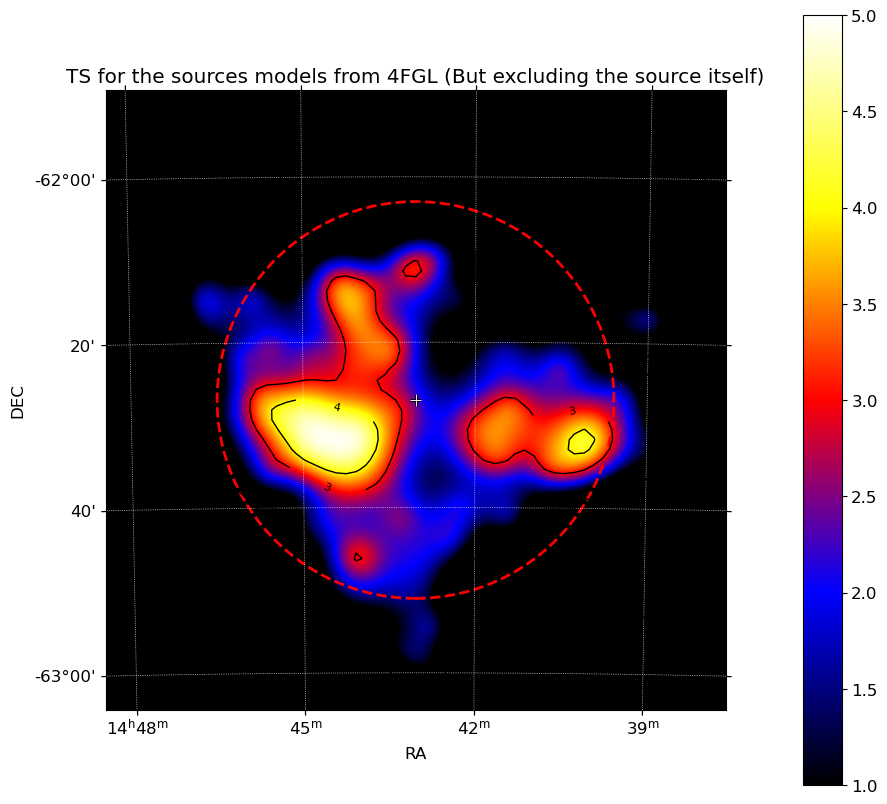

In [12]:
p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               label_ts_threshold=10.0)  # optional threshold for labeling
plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=6,vmin=1,vmax=5, levels=[0,3,4,5])
from astropy.coordinates import SkyCoord

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")
circle_pos = SkyCoord(ra=gta.roi.sources[0]['ra'], dec=gta.roi.sources[0]['dec'], unit='deg', frame='icrs')  # example coords

p.draw_circle(0.4,  # radius in degrees
              skydir=circle_pos,
              edgecolor='red',
              linewidth=2.0,
              linestyle='--')
plt.title("TS for the sources models from 4FGL (But excluding the source itself)")
plt.show()

In [49]:
plt.clf()
tsmap_postfit = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True)

2025-04-16 11:52:08 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-16 11:52:12 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-16 13:12:06 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-16 13:12:08 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-04-16 13:12:08 INFO    GTAnalysis.tsmap(): Execution time: 4800.70 s


<Figure size 640x480 with 0 Axes>

In [55]:
gta.print_roi()

2025-04-16 13:17:42 INFO    GTAnalysis.print_roi(): 
name                SpatialModel   SpectrumType     offset        ts       npred
--------------------------------------------------------------------------------
4FGL J1443.0-6227e  SpatialMap     PowerLaw          0.353    164.61       479.6
4FGL J1433.8-6357   PointSource    LogParabola       1.515     35.85       237.5
4FGL J1456.8-6122   PointSource    PowerLaw          2.296     11.07       618.1
4FGL J1422.5-6137   PointSource    PLSuperExpCuto    2.330   3745.40      8931.4
4FGL J1427.8-6051   PointSource    LogParabola       2.334    477.22     10514.5
4FGL J1424.2-6111c  PointSource    LogParabola       2.395     60.02      2858.9
4FGL J1435.8-6018   PointSource    LogParabola       2.396    115.35      4141.8
4FGL J1501.0-6310e  RadialGaussian LogParabola       2.397    155.70      5492.3
4FGL J1449.4-6026   PointSource    LogParabola       2.453     25.74       938.7
4FGL J1430.9-6024c  PointSource    LogParabola       2.5

<Figure size 640x480 with 0 Axes>

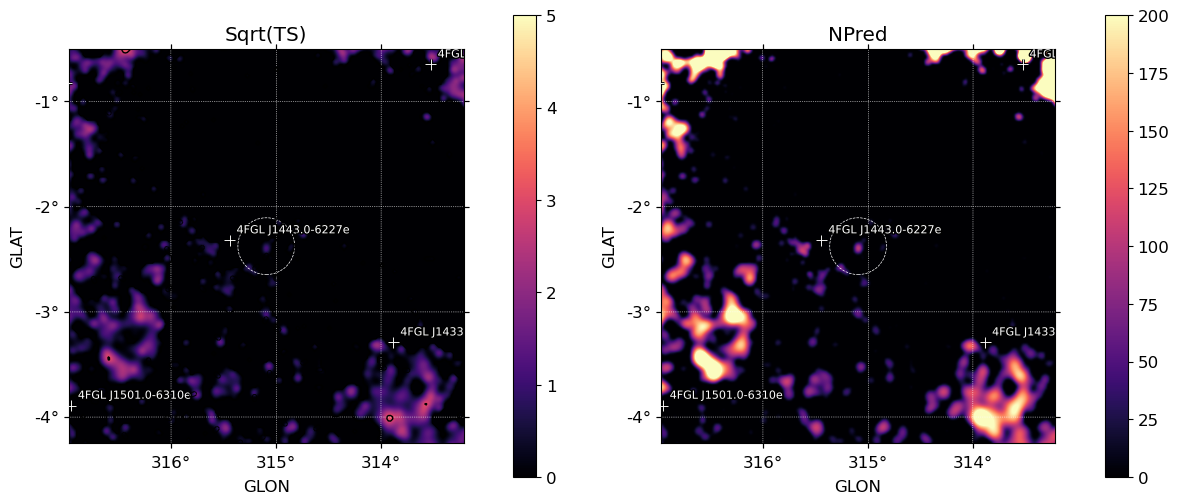

In [54]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_postfit['sqrt_ts'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 2)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_postfit['npred'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 2)
plt.gca().set_title('NPred')
plt.show()

In [57]:
plt.clf()
tsmap_excluded = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True, exclude = gta.roi.sources[0].name)

2025-04-16 13:57:00 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-16 13:57:05 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/fermipy/tsmap.py:933: RuntimeWarning: invalid value encountered in sqrt
  sqrt_ts_map = WcsNDMap(map_geom, ts_values**0.5)
2025-04-16 14:53:32 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-16 14:53:34 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-04-16 14:53:34 INFO    GTAnalysis.tsmap(): Execution time: 3393.86 s


<Figure size 640x480 with 0 Axes>

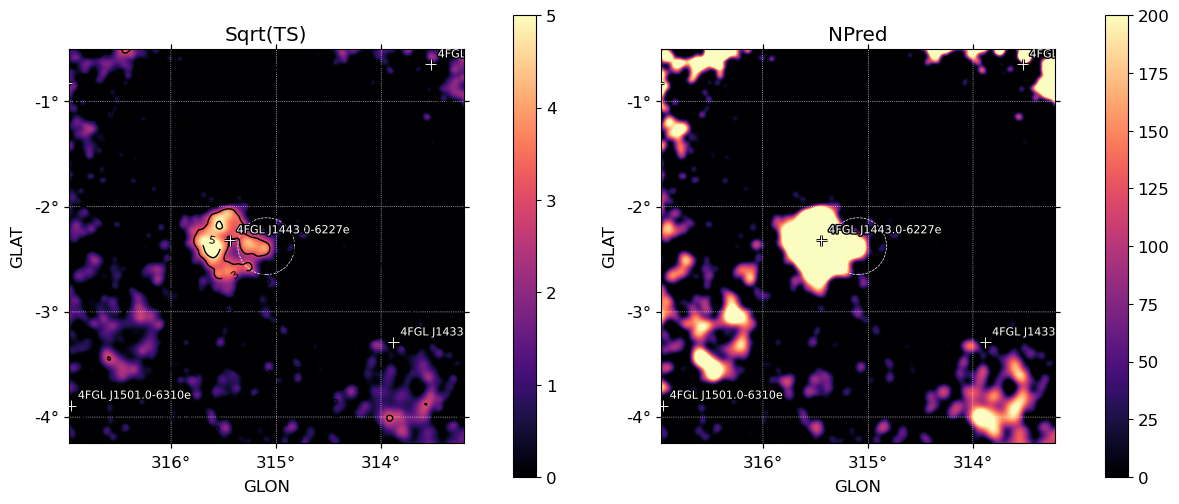

In [58]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_excluded['sqrt_ts'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 2)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_excluded['npred'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 2)
plt.gca().set_title('NPred')
plt.show()

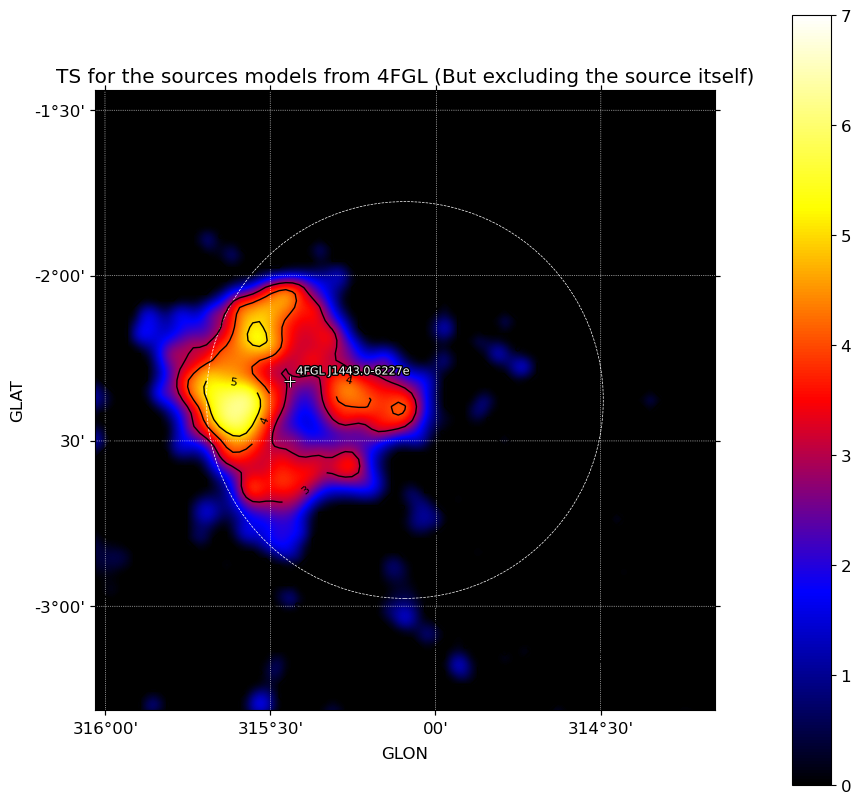

In [65]:
p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=100.0)  # optional threshold for labeling
plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=4,vmin=0,vmax=7, levels=[0,3,4,5])
from astropy.coordinates import SkyCoord

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")
circle_pos = SkyCoord(ra=gta.roi.sources[0]['ra'], dec=gta.roi.sources[0]['dec'], unit='deg', frame='icrs')  # example coords

p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')
plt.title("TS for the sources models from 4FGL (But excluding the source itself)")
plt.show()

In [63]:
print(tsmap_excluded['sqrt_ts'].geom.frame)

galactic


In [24]:
for src_info in gta.roi.sources:
    print(src_info)

Name           : 4FGL J1443.0-6227e
Associations   : ['4FGL J1443.0-6227e', 'RCW 86']
RA/DEC         :    220.760/   -62.450
GLON/GLAT      :    315.442/    -2.320
TS             : nan
Npred          : 714.17
Flux           : 1.686e-09 +/-      nan
EnergyFlux     : 1.369e-05 +/-      nan
SpatialModel   : SpatialMap
SpectrumType   : PowerLaw
Spectral Parameters
b'Prefactor'   :  1.695e-15 +/-        nan
b'Index'       :     -1.471 +/-        nan
b'Scale'       :  3.168e+04 +/-        nan
Name           : 4FGL J1433.8-6357
Associations   : ['4FGL J1433.8-6357']
RA/DEC         :    218.459/   -63.963
GLON/GLAT      :    313.883/    -3.290
TS             : nan
Npred          : 658.91
Flux           : 1.337e-09 +/-      nan
EnergyFlux     :  1.48e-06 +/-      nan
SpatialModel   : PointSource
SpectrumType   : LogParabola
Spectral Parameters
b'norm'        :   1.79e-13 +/-        nan
b'alpha'       :      2.109 +/-        nan
b'beta'        :     0.5626 +/-        nan
b'Eb'          :       1